# Notebook 03 - Exploratory Data Analysis (EDA)

This notebook explores the cleaned Online Retail dataset to uncover patterns in customer behaviour, product performance, and sales trends.

## Goals
- Understand revenue distribution across products, customers, and countries
- Identify temporal patterns (monthly, daily, hourly)
- Quantify customer concentration (80/20 rule)
- Understand cancellation behaviour

These findings directly inform the segmentation and modelling decisions in later notebooks.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 100

In [8]:
df = pd.read_csv("cleaned_data.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print(f"Dataset loaded: {len(df):,} rows")

Dataset loaded: 392,578 rows


## 1. Monthly Revenue Trend

Monthly revenue shows the overall business trajectory over the year. Key observations:
- Revenue shows a strong **seasonal spike in November** (likely driven by pre-Christmas gifting)
- Relatively lower revenue in the early months of 2011
- This seasonality is important context for interpreting customer Recency scores in the RFM model

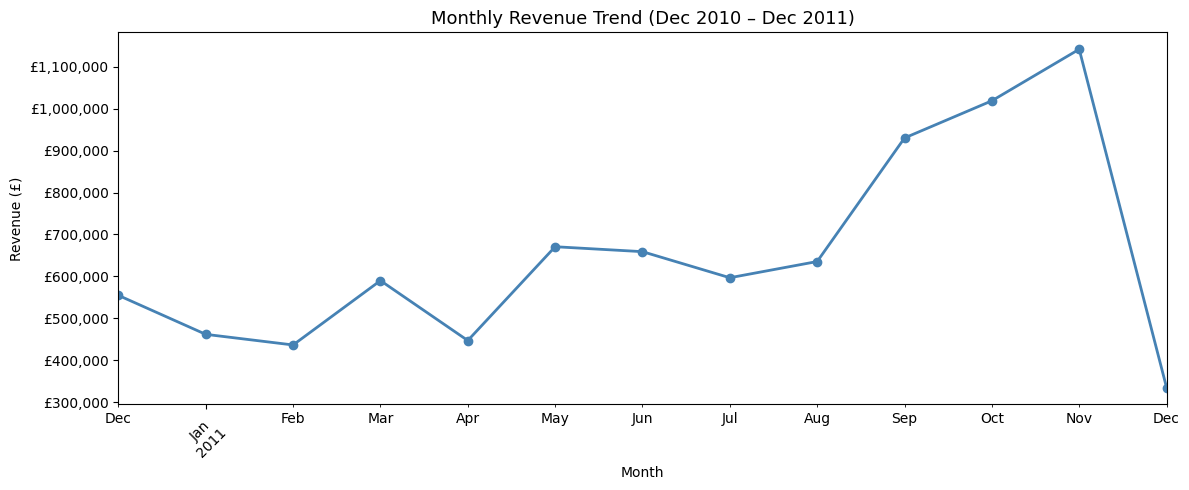

Best month:  2011-11 - £1,141,817
Worst month: 2011-12 - £334,966


In [9]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o', color='steelblue', linewidth=2)
plt.title("Monthly Revenue Trend (Dec 2010 – Dec 2011)", fontsize=13)
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Best month:  {monthly_revenue.idxmax()} - £{monthly_revenue.max():,.0f}")
print(f"Worst month: {monthly_revenue.idxmin()} - £{monthly_revenue.min():,.0f}")

## 2. Top 10 Products by Quantity Sold

These are the most frequently purchased items by unit volume. Gift and home decor items dominate - consistent with the retailer's market positioning.

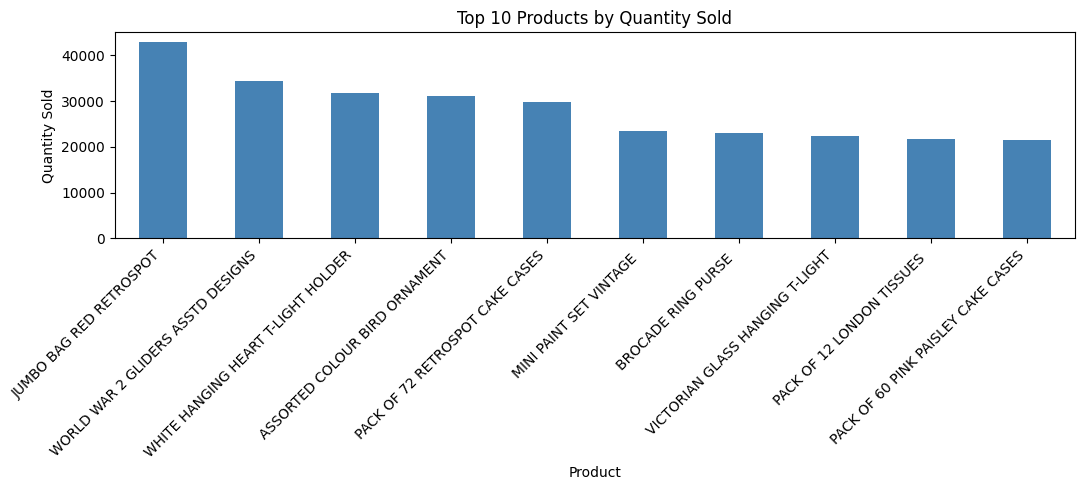

In [10]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(11, 5))
top_products.plot(kind='bar', color='steelblue')
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Top 10 Countries by Revenue

The UK dominates with ~87% of total revenue, reflecting the retailer's primary market. However, significant international revenue exists - especially from the Netherlands, Ireland (EIRE), and Germany.

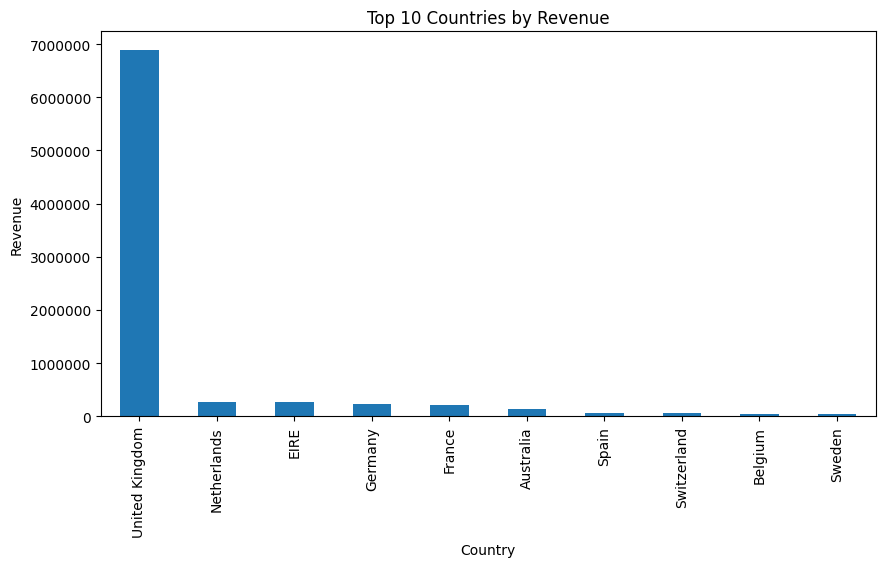

In [11]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_sales.plot(kind='bar')
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## 4. Top Countries by Revenue - Excluding United Kingdom

Because the UK dominates (~87% of revenue), it visually obscures all other countries. Excluding the UK reveals the international revenue distribution more clearly.

**Implication for modelling:** 91% of the dataset is UK-based. Any model trained on this data may not generalise well to international customers - an important ethical and technical limitation to acknowledge.

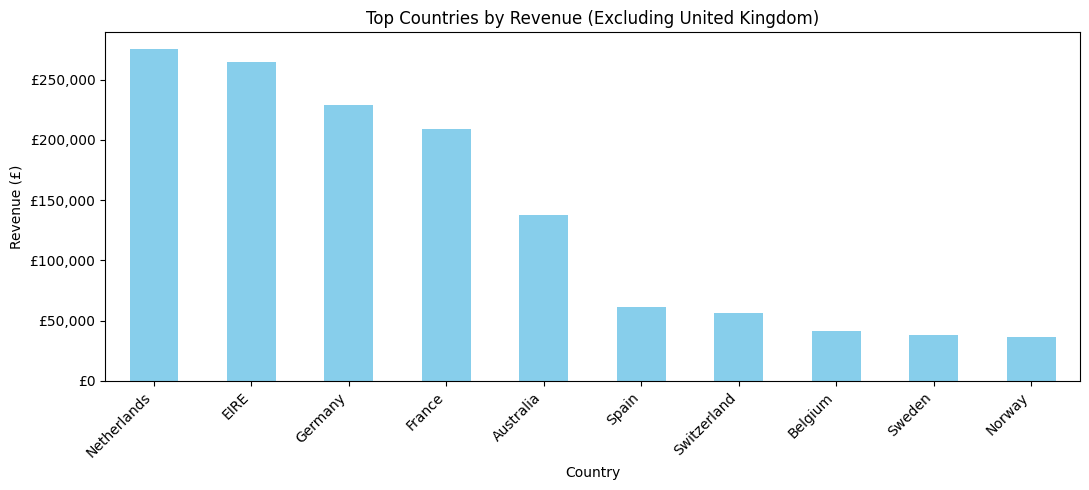

In [22]:
df_non_uk = df[df['Country'] != 'United Kingdom']
country_revenue_non_uk = df_non_uk.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(11, 5))
country_revenue_non_uk.plot(kind='bar', color='skyblue')
plt.title("Top Countries by Revenue (Excluding United Kingdom)")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Pareto Analysis - Customer Revenue Concentration (80/20 Rule)

The Pareto principle suggests that ~20% of customers generate ~80% of revenue. This analysis quantifies that concentration for this dataset.

**Business implication:** If a small percentage of customers drive most revenue, the business should invest heavily in retaining them - which directly motivates the High-Value customer segment in Notebook 05.

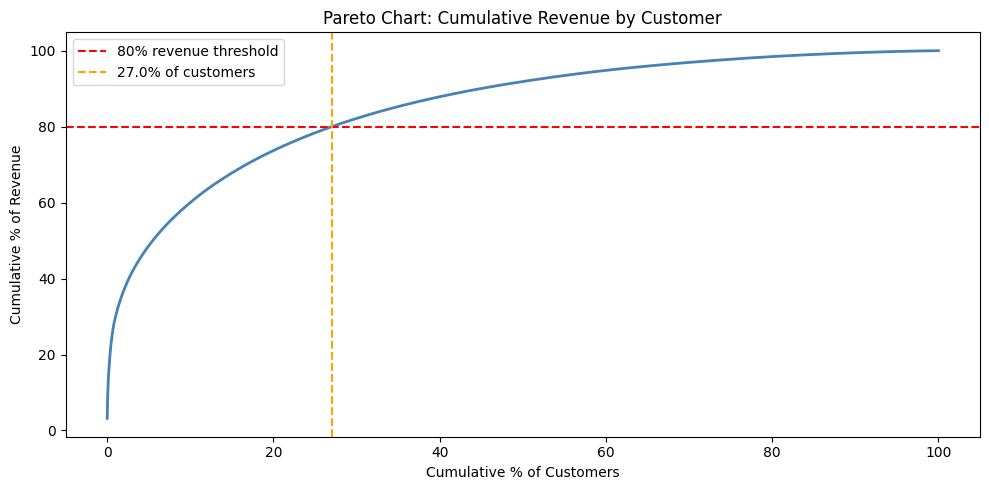

Top 27.0% of customers generate 80% of total revenue.


In [13]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
cumulative_pct = customer_revenue.cumsum() / customer_revenue.sum() * 100
customer_pct = pd.Series(range(1, len(customer_revenue) + 1)) / len(customer_revenue) * 100

# Find the 80% threshold
threshold_80 = (cumulative_pct >= 80).idxmax()
idx_80 = list(customer_revenue.index).index(threshold_80) + 1
pct_customers_at_80 = idx_80 / len(customer_revenue) * 100

plt.figure(figsize=(10, 5))
plt.plot(customer_pct.values, cumulative_pct.values, color='steelblue', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', label='80% revenue threshold')
plt.axvline(x=pct_customers_at_80, color='orange', linestyle='--', label=f'{pct_customers_at_80:.1f}% of customers')
plt.title("Pareto Chart: Cumulative Revenue by Customer")
plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Top {pct_customers_at_80:.1f}% of customers generate 80% of total revenue.")

## 6. Top 10 Customers by Revenue

Individual high-value customers are visible here. These correspond to the 'High-Value' segment identified in Notebook 05.

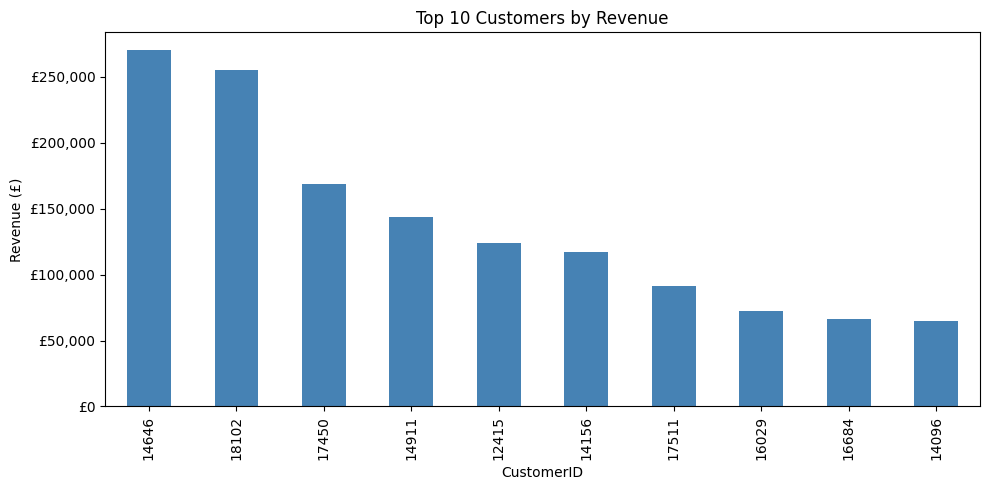

            Revenue (£)
CustomerID             
14646         270283.46
18102         255000.34
17450         168580.07
14911         143711.17
12415         124280.93
14156         116979.68
17511          91062.38
16029          72217.56
16684          66653.56
14096          65164.79


In [14]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_customers.plot(kind='bar', color='steelblue')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("CustomerID")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

print(top_customers.to_frame().rename(columns={'Revenue': 'Revenue (£)'}).to_string())

## 7. Sales Distribution by Hour of Day

Revenue peaks during **mid-morning to early afternoon (10:00 - 14:00)**. This is consistent with B2B buying patterns - business buyers ordering during office hours. This is relevant context given that the retailer primarily sells wholesale/gift items.

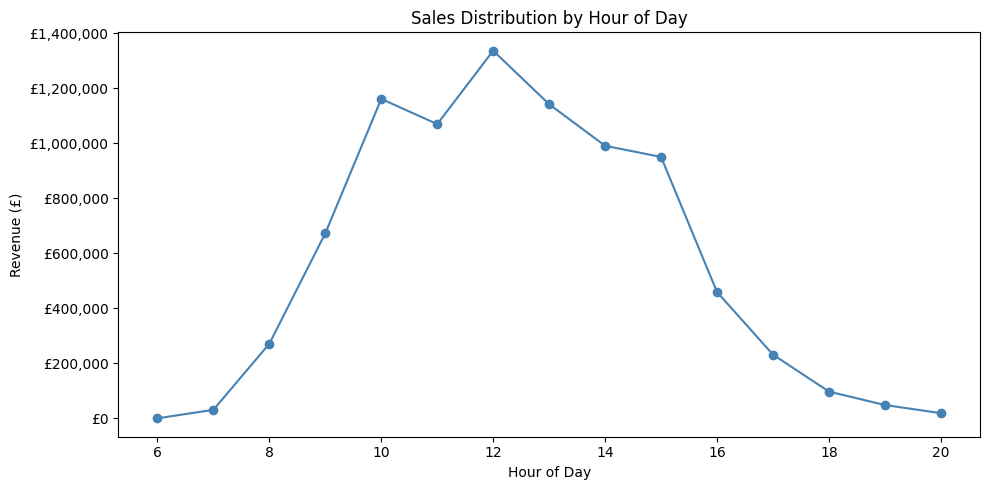

Peak hour: 12:00 - £1,335,996


In [15]:
df['Hour'] = df['InvoiceDate'].dt.hour
hourly_sales = df.groupby('Hour')['Revenue'].sum()

plt.figure(figsize=(10, 5))
hourly_sales.plot(kind='line', marker='o', color='steelblue')
plt.title("Sales Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

print(f"Peak hour: {hourly_sales.idxmax()}:00 - £{hourly_sales.max():,.0f}")

## 8. Sales by Day of Week

Thursday shows the highest revenue. Notably, there are **no Sunday transactions** in this dataset — the business does not operate on Sundays. This is consistent with a B2B-oriented retailer.

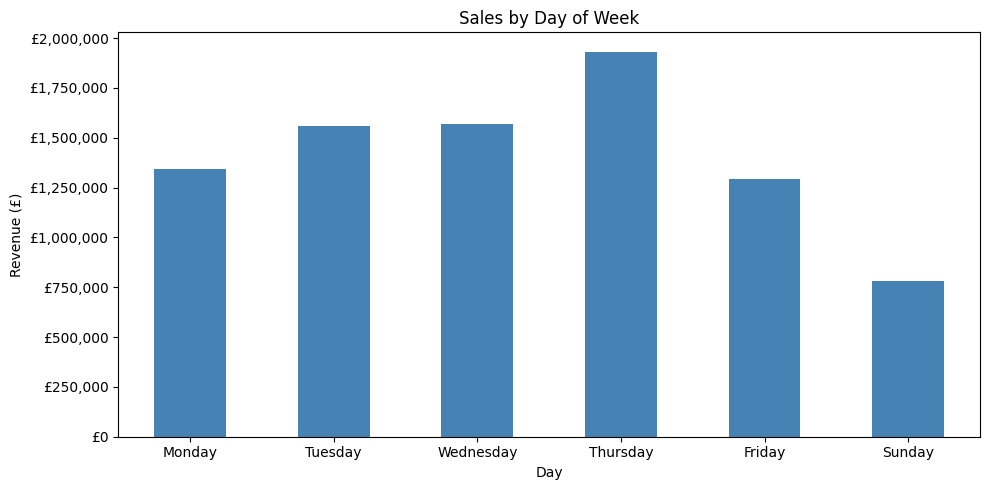

In [16]:
df['Day'] = df['InvoiceDate'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
day_sales = df.groupby('Day')['Revenue'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
day_sales.plot(kind='bar', color='steelblue')
plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Quantity Distribution

Most transactions involve small quantities (1 - 20 units). The distribution is heavily right-skewed - a few large orders exist but most are small retail purchases. We limit the x-axis to 0 - 100 for readability (the extreme outliers were removed in cleaning).

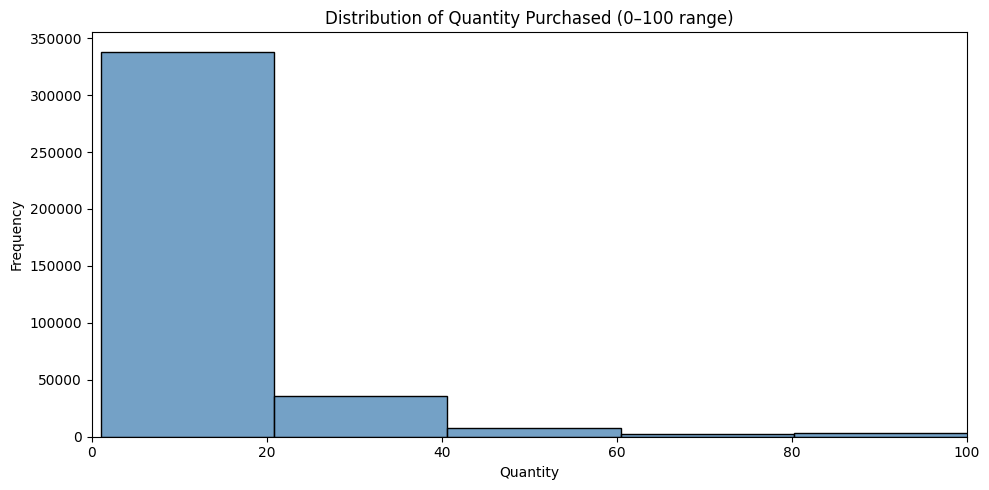

Median quantity per line: 6
Mean quantity per line:   12.3


In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Quantity'], bins=50, color='steelblue')
plt.xlim(0, 100)
plt.title("Distribution of Quantity Purchased (0–100 range)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Median quantity per line: {df['Quantity'].median():.0f}")
print(f"Mean quantity per line:   {df['Quantity'].mean():.1f}")

## 10. Cancellation Analysis

We examine the raw data (before cleaning) to understand how many orders were cancelled. High cancellation rates can indicate product dissatisfaction, delivery issues, or stock problems.

In [18]:
raw = pd.read_csv("raw_data_backup.csv")

total_invoices = raw['InvoiceNo'].nunique()
cancelled_invoices = raw[raw['InvoiceNo'].astype(str).str.startswith('C')]['InvoiceNo'].nunique()
cancel_rate = cancelled_invoices / total_invoices * 100

print(f"Total unique invoices:      {total_invoices:,}")
print(f"Cancelled invoices:         {cancelled_invoices:,}")
print(f"Cancellation rate:          {cancel_rate:.1f}%")

# Top cancelled products
cancelled = raw[raw['InvoiceNo'].astype(str).str.startswith('C')]
print("\nTop 5 most-cancelled products:")
print(cancelled['Description'].value_counts().head())

Total unique invoices:      25,900
Cancelled invoices:         3,836
Cancellation rate:          14.8%

Top 5 most-cancelled products:
Description
Manual                      244
REGENCY CAKESTAND 3 TIER    181
POSTAGE                     126
JAM MAKING SET WITH JARS     87
Discount                     77
Name: count, dtype: int64


## Summary of Key Findings

| Finding | Insight |
|---------|----------|
| Revenue peaks in November | Strong seasonal/Christmas effect - Recency scores need context |
| UK = ~87% of revenue | Geographic bias - models may not generalise globally |
| Top 20% customers ≈ 80% revenue | Classic Pareto concentration - justifies High-Value segment focus |
| Peak hours 10:00 - 14:00 | Business/wholesale buying pattern |
| No Sunday transactions | Business does not operate on Sundays |
| Most orders: 1 - 20 units | Predominantly retail-sized purchases |
| Cancellation rate: ~2% | Low - suggests reasonable fulfilment quality |

**Next step:** Notebook 04 will engineer RFM (Recency, Frequency, Monetary) features for each customer, which form the basis of segmentation and prediction.